In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn 
import numpy as np

In [4]:
df = pd.read_csv("movie_roi.csv")

In [6]:
df.columns

Index(['movie', 'year', 'production_budget', 'domestic_gross', 'foreign_gross',
       'worldwide_gross', 'month', 'profit', 'profit_margin', 'roi',
       'pct_foreign', 'match_key', 'popularity', 'release_date',
       'original_language', 'vote_average', 'vote_count', 'genres', 'Action',
       'Adventure', 'Animation', 'Comedy', 'Crime', 'Documentary', 'Drama',
       'Family', 'Fantasy', 'History', 'Horror', 'Music', 'Mystery', 'Romance',
       'Science Fiction', 'TV Movie', 'Thriller', 'War', 'Western',
       'no_reported_box_office'],
      dtype='object')

In [7]:
df["production_budget"].describe()

count    1.602000e+03
mean     4.275294e+07
std      5.489471e+07
min      2.000000e+04
25%      7.000000e+06
50%      2.100000e+07
75%      5.450000e+07
max      4.250000e+08
Name: production_budget, dtype: float64

In [8]:
df["budget_level"] = pd.qcut(
    df["production_budget"],
    q=3,
    labels=["Low", "Medium", "High"]
)

df["budget_level"].value_counts()

budget_level
Medium    535
Low       534
High      533
Name: count, dtype: int64

In [9]:
df.groupby("budget_level", observed=True)["production_budget"].agg(["min", "max"])

,min,max
budget_level,,
Low,20000,10500000
Medium,10600000,38000000
High,39000000,425000000


In [10]:
df.groupby("budget_level", observed=True).apply(
    lambda x: x["popularity"].corr(x["roi"])
)

C:\Users\bandi\AppData\Local\Temp\ipykernel_29772\1380240473.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df.groupby("budget_level", observed=True).apply(


budget_level
Low       0.178267
Medium    0.351318
High      0.325197
dtype: float64

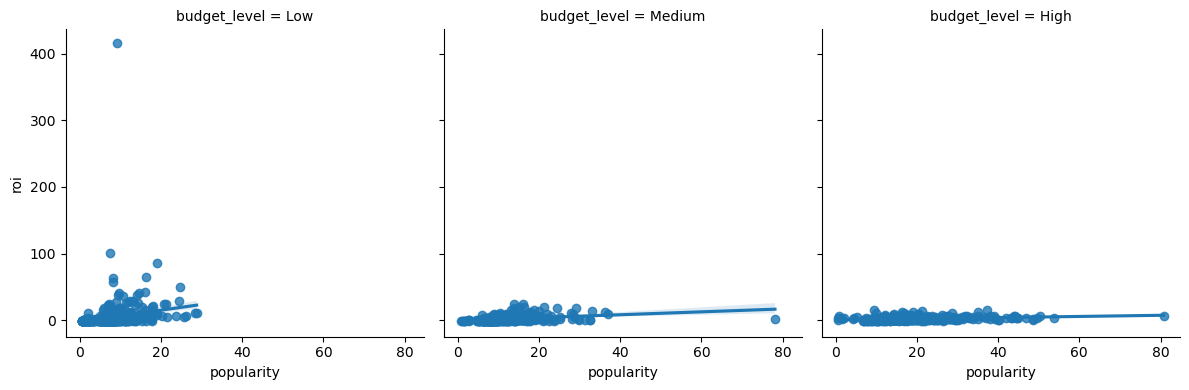

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.lmplot(
    data=df,
    x="popularity",
    y="roi",
    col="budget_level",
    col_order=["Low", "Medium", "High"],
    height=4,
    aspect=1
)

plt.show()
#The dots represent individual movies, while the fitted line helps us see whether ROI generally increases or decreases as popularity increases.

In [12]:
df.nlargest(10, "roi")[
    ["movie", "production_budget", "popularity", "roi", "budget_level"]
]

,movie,production_budget,popularity,roi,budget_level
1581,The Gallows,100000,9.166,415.564740,Low
1492,The Devil Inside,1000000,7.403,100.759490,Low
1482,Saw,1200000,19.127,85.566689,Low
1456,Insidious,1500000,16.197,65.580591,Low
1493,Unfriended,1000000,8.120,63.364198,Low
1350,Paranormal Activity 2,3000000,8.163,58.170677,Low
1234,Get Out,5000000,24.739,50.073590,Low
1457,Moonlight,1500000,15.948,42.497008,Low
1495,Chernobyl Diaries,1000000,14.658,41.411721,Low
1235,Paranormal Activity 3,5000000,9.669,40.407969,Low


In [13]:
df["roi"].quantile(0.99)

np.float64(28.22223221533335)

In [14]:
roi_99 = df["roi"].quantile(0.99)

df_visual = df[df["roi"] <= roi_99].copy()

df_visual.shape

(1488, 39)

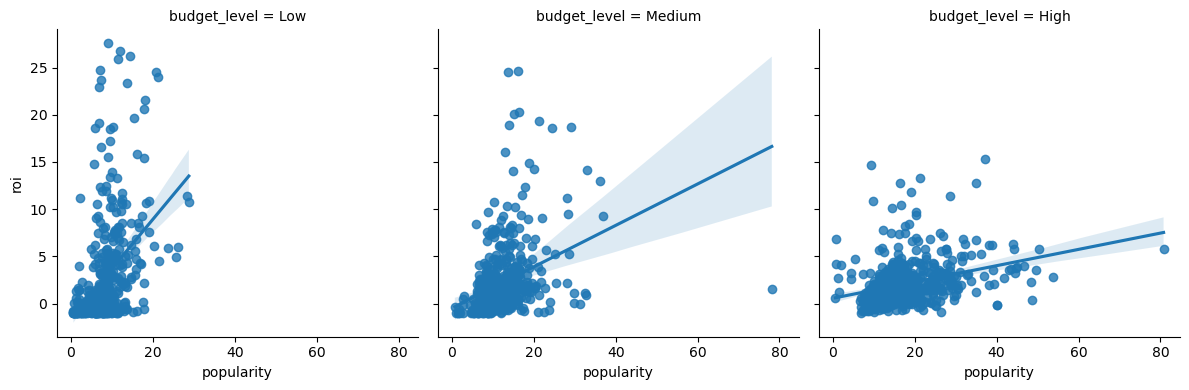

In [15]:
sns.lmplot(
    data=df_visual,
    x="popularity",
    y="roi",
    col="budget_level",
    col_order=["Low", "Medium", "High"],
    height=4,
    aspect=1
)

plt.show()

In [16]:
df[["vote_average", "popularity", "worldwide_gross"]].describe()

,vote_average,popularity,worldwide_gross
count,1602.000000,1602.000000,1.602000e+03
mean,6.272222,12.526468,1.370038e+08
std,0.927481,7.930781,2.366298e+08
min,0.800000,0.600000,0.000000e+00
25%,5.800000,7.865000,6.765501e+06
50%,6.300000,10.887000,4.851074e+07
75%,6.900000,15.529000,1.521310e+08
max,10.000000,80.773000,2.776345e+09


In [17]:
df[["vote_average", "popularity", "worldwide_gross"]].isnull().sum()

vote_average       0
popularity         0
worldwide_gross    0
dtype: int64

In [18]:
df["no_reported_box_office"].value_counts()

no_reported_box_office
False    1504
True       98
Name: count, dtype: int64

In [19]:
(df["worldwide_gross"] == 0).sum()

np.int64(98)

In [20]:
df_box = df[df["no_reported_box_office"] == False].copy()

df_box.shape

(1504, 39)

In [21]:
df_box[
    ["vote_average", "popularity", "worldwide_gross"]
].corr()

,vote_average,popularity,worldwide_gross
vote_average,1.000000,0.317366,0.260209
popularity,0.317366,1.000000,0.631006
worldwide_gross,0.260209,0.631006,1.000000


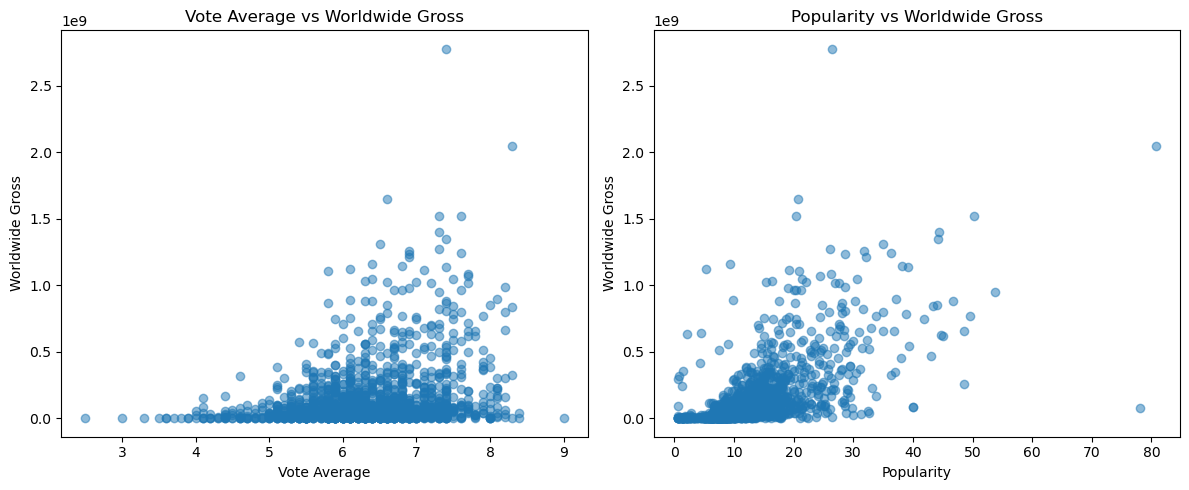

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(
    df_box["vote_average"],
    df_box["worldwide_gross"],
    alpha=0.5
)

axes[0].set_xlabel("Vote Average")
axes[0].set_ylabel("Worldwide Gross")
axes[0].set_title("Vote Average vs Worldwide Gross")


axes[1].scatter(
    df_box["popularity"],
    df_box["worldwide_gross"],
    alpha=0.5
)

axes[1].set_xlabel("Popularity")
axes[1].set_ylabel("Worldwide Gross")
axes[1].set_title("Popularity vs Worldwide Gross")

plt.tight_layout()
plt.show()

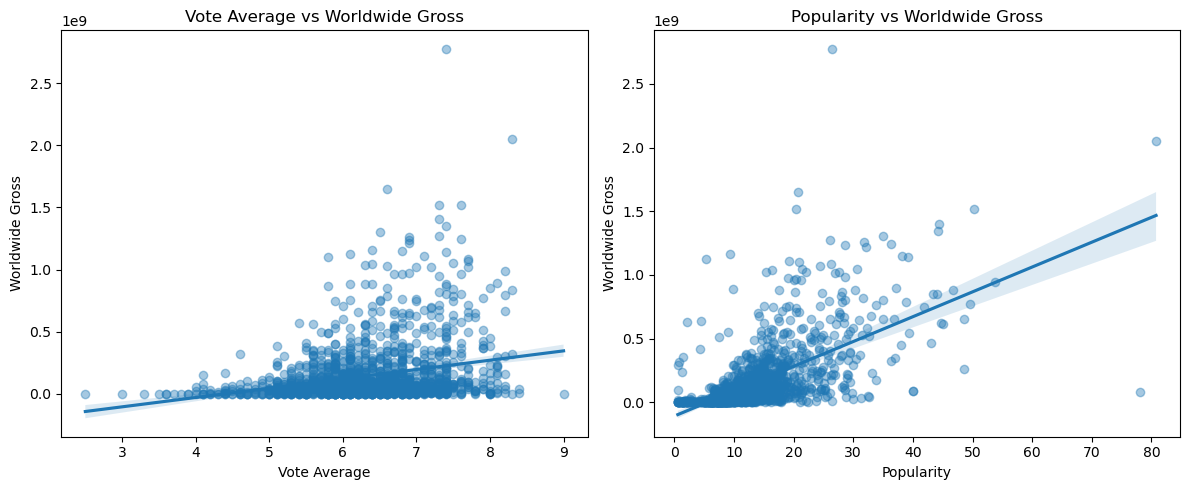

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.regplot(
    data=df_box,
    x="vote_average",
    y="worldwide_gross",
    ax=axes[0],
    scatter_kws={"alpha": 0.4}
)

axes[0].set_title("Vote Average vs Worldwide Gross")
axes[0].set_xlabel("Vote Average")
axes[0].set_ylabel("Worldwide Gross")


sns.regplot(
    data=df_box,
    x="popularity",
    y="worldwide_gross",
    ax=axes[1],
    scatter_kws={"alpha": 0.4}
)

axes[1].set_title("Popularity vs Worldwide Gross")
axes[1].set_xlabel("Popularity")
axes[1].set_ylabel("Worldwide Gross")

plt.tight_layout()
plt.show()

In [25]:
#3rd question
top_profit = df.nlargest(10, "profit")[
    ["movie", "production_budget", "worldwide_gross", "profit", "roi"]
]

top_profit

,movie,production_budget,worldwide_gross,profit,roi
0,Avatar,425000000,2776345279,2.351345e+09,5.532577
3,Avengers: Infinity War,300000000,2048134200,1.748134e+09,5.827114
23,Jurassic World,215000000,1648854864,1.433855e+09,6.669092
45,Furious 7,190000000,1518722794,1.328723e+09,6.993278
18,The Avengers,225000000,1517935897,1.292936e+09,5.746382
27,Black Panther,200000000,1348258224,1.148258e+09,5.741291
73,Jurassic World: Fallen Kingdom,170000000,1305772799,1.135773e+09,6.681016
102,Frozen,150000000,1272469910,1.122470e+09,7.483133
89,Beauty and the Beast,160000000,1259199706,1.099200e+09,6.869998
296,Minions,74000000,1160336173,1.086336e+09,14.680219


In [26]:
top_roi = df.nlargest(10, "roi")[
    ["movie", "production_budget", "worldwide_gross", "profit", "roi"]
]

top_roi

,movie,production_budget,worldwide_gross,profit,roi
1581,The Gallows,100000,41656474,41556474.0,415.564740
1492,The Devil Inside,1000000,101759490,100759490.0,100.759490
1482,Saw,1200000,103880027,102680027.0,85.566689
1456,Insidious,1500000,99870886,98370886.0,65.580591
1493,Unfriended,1000000,64364198,63364198.0,63.364198
1350,Paranormal Activity 2,3000000,177512032,174512032.0,58.170677
1234,Get Out,5000000,255367951,250367951.0,50.073590
1457,Moonlight,1500000,65245512,63745512.0,42.497008
1495,Chernobyl Diaries,1000000,42411721,41411721.0,41.411721
1235,Paranormal Activity 3,5000000,207039844,202039844.0,40.407969


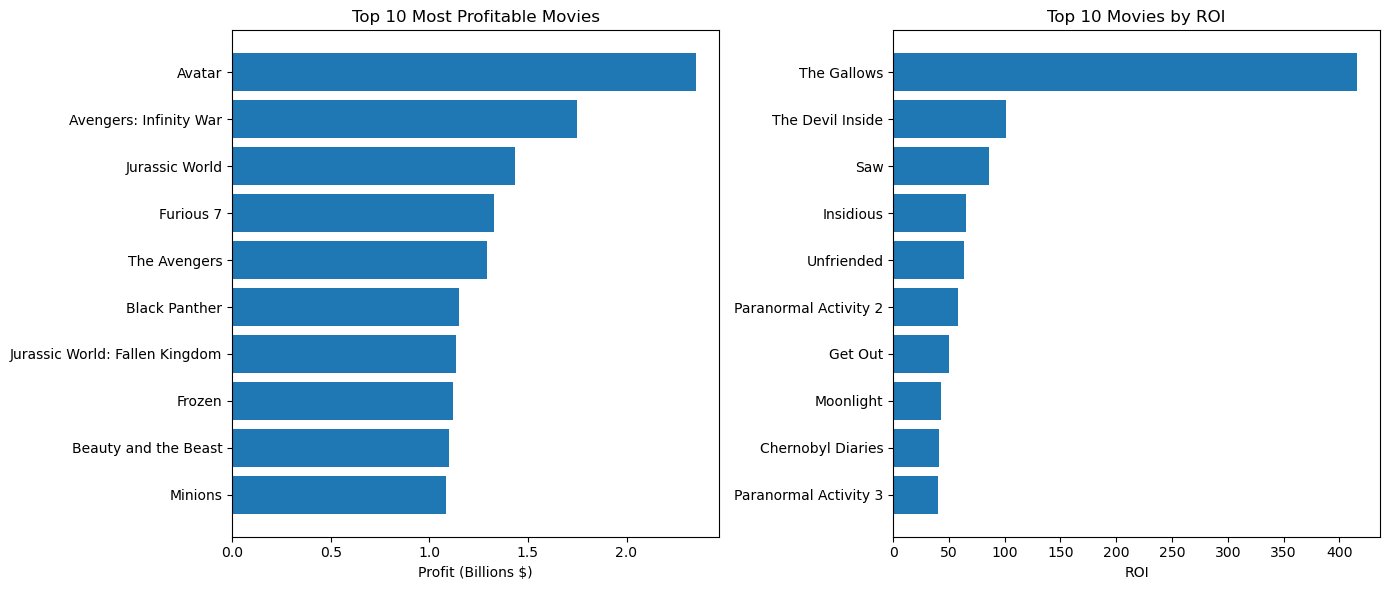

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Top 10 movies by profit
profit_plot = top_profit.sort_values("profit")

axes[0].barh(
    profit_plot["movie"],
    profit_plot["profit"] / 1_000_000_000
)

axes[0].set_xlabel("Profit (Billions $)")
axes[0].set_title("Top 10 Most Profitable Movies")


# Top 10 movies by ROI
roi_plot = top_roi.sort_values("roi")

axes[1].barh(
    roi_plot["movie"],
    roi_plot["roi"]
)

axes[1].set_xlabel("ROI")
axes[1].set_title("Top 10 Movies by ROI")

plt.tight_layout()
plt.show()

In [2]:
import pandas as pd
import numpy as np
import plotly.express as px

df = pd.read_csv("movie_roi.csv")

df.shape

(1602, 38)

In [3]:
variables = [
    "popularity",
    "production_budget",
    "domestic_gross",
    "foreign_gross",
    "worldwide_gross",
    "vote_average"
]

corr_data = df[df["no_reported_box_office"] == False].copy()

corr_data = corr_data[
    variables + ["roi"]
].replace([np.inf, -np.inf], np.nan).dropna()

In [5]:
roi_correlations = (
    corr_data[variables + ["roi"]]
    .corr()["roi"]
    .drop("roi")
    .sort_values()
)

roi_correlations

production_budget   -0.056115
vote_average         0.031659
popularity           0.062847
foreign_gross        0.063443
worldwide_gross      0.078030
domestic_gross       0.098775
Name: roi, dtype: float64

In [8]:
# Friendly names for displaying variables
variable_names = {
    "popularity": "Popularity",
    "production_budget": "Production Budget",
    "domestic_gross": "Domestic Gross",
    "foreign_gross": "Foreign Gross",
    "worldwide_gross": "Worldwide Gross",
    "vote_average": "Vote Average"
}

# Remove only the top 1% extreme ROI values for clearer visualization
roi_99 = corr_data["roi"].quantile(0.99)

roi_visual = corr_data[
    corr_data["roi"] <= roi_99
].copy()

print("Movies in correlation analysis:", len(corr_data))
print("Movies shown in visualization:", len(roi_visual))
print("99th percentile ROI:", round(roi_99, 2))

Movies in correlation analysis: 1504
Movies shown in visualization: 1488
99th percentile ROI: 28.22


In [9]:
# Add movie names for hover information
roi_visual["movie"] = df.loc[roi_visual.index, "movie"]

In [11]:
import plotly.graph_objects as go

fig = go.Figure()

correlations_visual = {}

for i, variable in enumerate(variables):

    # Correlation for the data visible in this chart
    r = roi_visual[variable].corr(roi_visual["roi"])
    correlations_visual[variable] = r

    fig.add_trace(
        go.Scatter(
            x=roi_visual[variable],
            y=roi_visual["roi"],
            mode="markers",
            visible=(i == 0),
            customdata=roi_visual[["movie"]],
            hovertemplate=(
                "<b>%{customdata[0]}</b><br>"
                + variable_names[variable] + ": %{x}<br>"
                + "ROI: %{y:.2f}"
                + "<extra></extra>"
            ),
            name=variable_names[variable]
        )
    )

In [12]:
buttons = []

for i, variable in enumerate(variables):

    visibility = [False] * len(variables)
    visibility[i] = True

    r = correlations_visual[variable]

    buttons.append(
        dict(
            label=variable_names[variable],
            method="update",
            args=[
                {"visible": visibility},
                {
                    "title": (
                        f"{variable_names[variable]} vs ROI "
                        f"(r = {r:.3f})"
                    ),
                    "xaxis": {
                        "title": variable_names[variable]
                    }
                }
            ]
        )
    )

fig.update_layout(
    title=(
        f"{variable_names[variables[0]]} vs ROI "
        f"(r = {correlations_visual[variables[0]]:.3f})"
    ),

    xaxis_title=variable_names[variables[0]],
    yaxis_title="ROI",

    updatemenus=[
        dict(
            buttons=buttons,
            direction="down",
            x=0,
            y=1.15,
            showactive=True
        )
    ],

    height=600
)

fig.show()

In [15]:
from plotly.subplots import make_subplots
import plotly.graph_objects as go

# Add movie names for hover
plot_data = roi_visual.copy()
plot_data["movie"] = df.loc[plot_data.index, "movie"]

variables_order = [
    "popularity",
    "production_budget",
    "domestic_gross",
    "foreign_gross",
    "worldwide_gross",
    "vote_average"
]

positions = [
    (1, 1), (1, 2),
    (2, 1), (2, 2),
    (3, 1), (3, 2)
]

fig = make_subplots(
    rows=3,
    cols=2,
    horizontal_spacing=0.12,
    vertical_spacing=0.12,
    subplot_titles=[
        f"Popularity vs ROI  |  r = {roi_correlations['popularity']:.3f}",
        f"Production Budget vs ROI  |  r = {roi_correlations['production_budget']:.3f}",
        f"Domestic Gross vs ROI  |  r = {roi_correlations['domestic_gross']:.3f}",
        f"Foreign Gross vs ROI  |  r = {roi_correlations['foreign_gross']:.3f}",
        f"Worldwide Gross vs ROI  |  r = {roi_correlations['worldwide_gross']:.3f}",
        f"Vote Average vs ROI  |  r = {roi_correlations['vote_average']:.3f}"
    ]
)

for variable, (row, col) in zip(variables_order, positions):

    fig.add_trace(
        go.Scatter(
            x=plot_data[variable],
            y=plot_data["roi"],
            mode="markers",
            marker=dict(
                size=6,
                opacity=0.5
            ),
            customdata=plot_data[["movie"]],
            hovertemplate=(
                "<b>%{customdata[0]}</b><br>"
                + variable_names[variable]
                + ": %{x}<br>"
                + "ROI: %{y:.2f}"
                + "<extra></extra>"
            ),
            showlegend=False
        ),
        row=row,
        col=col
    )

    # ROI = 0 reference line
    fig.add_hline(
        y=0,
        line_dash="dash",
        line_width=1,
        row=row,
        col=col
    )

    fig.update_xaxes(
        title_text=variable_names[variable],
        row=row,
        col=col
    )

    fig.update_yaxes(
        title_text="ROI",
        range=[-1, roi_99],
        row=row,
        col=col
    )

# Dollar formatting for monetary variables
for row, col in [(1, 2), (2, 1), (2, 2), (3, 1)]:
    fig.update_xaxes(
        tickprefix="$",
        tickformat="~s",
        row=row,
        col=col
    )

fig.update_layout(
    title={
        "text":
        "<b>Movie Variables and Return on Investment (ROI)</b>"
        "<br><sup>"
        "Correlation values use all 1,504 valid movies. "
        "For readability, scatter plots omit only the top 1% extreme ROI values."
        "</sup>",
        "x": 0.5
    },
    height=1200,
    width=1050,
    margin=dict(t=120, l=60, r=40, b=50),
    hovermode="closest"
)

fig.show()

In [16]:
from plotly.subplots import make_subplots
import plotly.graph_objects as go
import pandas as pd

variable_names = {
    "popularity": "Popularity",
    "production_budget": "Production Budget",
    "domestic_gross": "Domestic Gross",
    "foreign_gross": "Foreign Gross",
    "worldwide_gross": "Worldwide Gross",
    "vote_average": "Vote Average"
}

variables_order = [
    "popularity",
    "production_budget",
    "domestic_gross",
    "foreign_gross",
    "worldwide_gross",
    "vote_average"
]

# Create a summary for each variable
summary_data = {}

for variable in variables_order:

    temp = corr_data[[variable, "roi"]].copy()

    temp["Level"] = pd.qcut(
        temp[variable],
        q=4,
        labels=["Low", "Medium", "High", "Very High"],
        duplicates="drop"
    )

    summary = (
        temp.groupby("Level", observed=True)
        .agg(
            median_roi=("roi", "median"),
            mean_roi=("roi", "mean"),
            movies=("roi", "size")
        )
        .reset_index()
    )

    summary_data[variable] = summary

In [17]:
fig = make_subplots(
    rows=3,
    cols=2,
    subplot_titles=[
        f"Popularity  |  r = {roi_correlations['popularity']:.3f}",
        f"Production Budget  |  r = {roi_correlations['production_budget']:.3f}",
        f"Domestic Gross  |  r = {roi_correlations['domestic_gross']:.3f}",
        f"Foreign Gross  |  r = {roi_correlations['foreign_gross']:.3f}",
        f"Worldwide Gross  |  r = {roi_correlations['worldwide_gross']:.3f}",
        f"Vote Average  |  r = {roi_correlations['vote_average']:.3f}"
    ],
    vertical_spacing=0.14,
    horizontal_spacing=0.12
)

positions = [
    (1, 1), (1, 2),
    (2, 1), (2, 2),
    (3, 1), (3, 2)
]

for variable, (row, col) in zip(variables_order, positions):

    summary = summary_data[variable]

    fig.add_trace(
        go.Scatter(
            x=summary["Level"],
            y=summary["median_roi"],
            mode="lines+markers",
            marker=dict(size=11),
            line=dict(width=3),

            customdata=summary[
                ["mean_roi", "movies"]
            ],

            hovertemplate=(
                "<b>%{x}</b><br>"
                "Median ROI: %{y:.2f}<br>"
                "Mean ROI: %{customdata[0]:.2f}<br>"
                "Movies: %{customdata[1]}"
                "<extra></extra>"
            ),

            showlegend=False
        ),
        row=row,
        col=col
    )

    fig.update_xaxes(
        title_text=f"{variable_names[variable]} Level",
        row=row,
        col=col
    )

    fig.update_yaxes(
        title_text="Median ROI",
        row=row,
        col=col
    )

fig.update_layout(
    title={
        "text":
        "<b>How Movie Characteristics Relate to ROI</b>"
        "<br><sup>"
        "Movies are divided into four equal groups for each variable. "
        "Lines show median ROI; r shows Pearson correlation."
        "</sup>",
        "x": 0.5
    },

    height=1150,
    width=950,
    margin=dict(t=120, l=60, r=40, b=50),
    hovermode="closest"
)

fig.show()